# Image Segmentation on anevrisms

## 1. Applying image filtering

Some of the anevrisms are already segmented (patient 2 and patient 3): to remove the segmentation, one can apply a mean filter on the segmentaiton line: the idea is to remove the segmentation line, then replace its value with the value of a 2*2 mean filter

In [52]:
!pip install scikit-image
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 5.1 MB/s eta 0:00:0000:0100:01


In [3]:
!ls imgs

STD_AOST_PreStent.tif  patient1_seg.tif  patient3.tif
patient1_no_seg.bmp    patient2.tif


/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_20931/946815876.py:27: RuntimeWarning: invalid value encountered in cast
  img2[pixelx,pixely] = np.mean(mean_list, axis=0)


Text(0.5, 1.0, 'anv3')

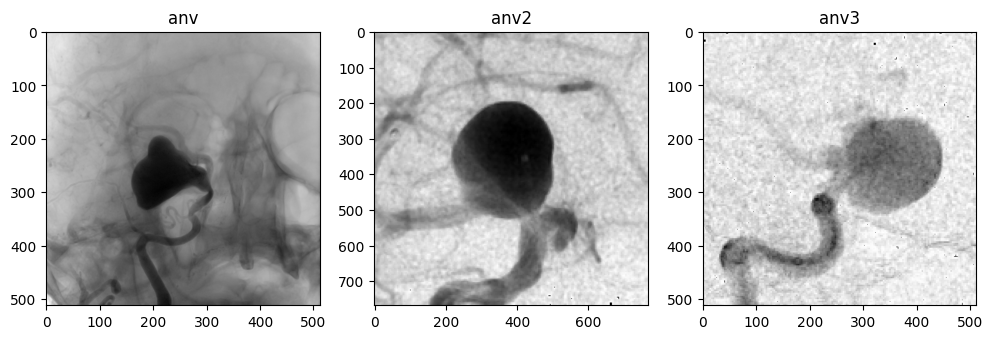

In [11]:
from skimage import graph, data, io, segmentation, color
import os
from matplotlib import pyplot as plt
from skimage.measure import regionprops
from skimage import draw
import numpy as np

anv = io.imread(os.path.join('imgs', 'patient1_no_seg.bmp'))
anv2 = io.imread(os.path.join('imgs', 'patient2.tif'))
anv3 = io.imread(os.path.join('imgs', 'patient3.tif'))
#anv = color.gray2rgb(anv)

def remove_seg(img):
    """return an image without its segmentations, using a mean filter.
    Mean filter 2*2 is applied only on the segmenation, leaving the rest as it is"""
    img2 = img.copy()
    for pixelx in range(img.shape[0]):
        for pixely in range(img.shape[1]):
    #         if np.all(img[pixelx,pixely]==np.array([0,255,255])) or np.all(img[pixelx,pixely]==np.array([0,255,0])) or\
    #         np.all(img[pixelx,pixely]==np.array([255,255,0])) or np.all(img[pixelx,pixely]==np.array([255,0,255])):
            if np.any(img[pixelx,pixely]==np.array([255,255,255])):
                mean_list = []
                for px in range(pixelx-1,pixelx+2):
                    for py in range(pixely-1, pixely+2):
                        if px < img.shape[0] and py < img.shape[1] and not np.any(img[px,py]==[255,255,255]) :
                            mean_list.append(img[px,py])

                    img2[pixelx,pixely] = np.mean(mean_list, axis=0)
        
    return img2

seg_ref_anv2 = anv2.copy()
anv2 = remove_seg(anv2)
anv3 = remove_seg(anv3)
fig, ax = plt.subplots(ncols=3, figsize=(12, 16))
ax[0].imshow(color.gray2rgb(anv))
ax[0].set_title("anv")
ax[1].imshow(anv2)
ax[1].set_title("anv2")
seg_ref_anv2_2 = seg_ref_anv2 * (seg_ref_anv2 == [0,255,0])

ax[2].imshow(anv3)
ax[2].set_title("anv3")


## 2. Applying Thresholding: 
skimage has a method to test and try all thresholds, so we can pick the one that works the best

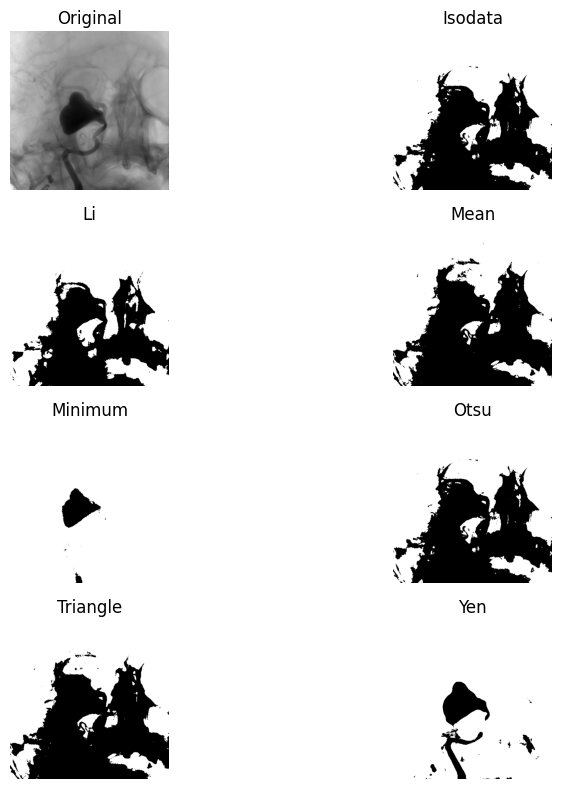

In [12]:
# testing thresholding on images
from skimage.filters import try_all_threshold

fig, ax = try_all_threshold(anv, figsize=(10, 8), verbose=False)
plt.show()

## 3. Applying Graph Cuts :

In order to compute a graph given an image, one should use an oversegmenting method. The oversegmenting method will regroup similar neighbor pixels into clusters. Then a graph (Region Adgency Graph) is established, assessing the difference between each clusters (nodes in graph), and attribuing edges (weights can be understood as strengths/differences between each clusters). Finally, Normalized cut will be applied for object segmentations. The goal of Normalized cut is to find edges 


In a nutshell; GraphCuts consists of:
- oversegmenting method
- normalized cuts
- get labels

Text(0.5, 1.0, 'anv3')

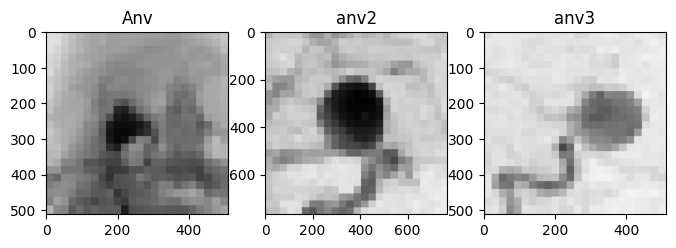

In [79]:
# using graph based method:
# practising over segmentation

def slic_method(img):
    if len(img.shape)> 2:
        img = color.rgb2gray(img)
    labels = segmentation.slic(img, compactness=30, n_segments=600, channel_axis=None)
    labels = labels + 1  # So that no labelled region is 0 and ignored by regionprops
    label_rgb = color.label2rgb(labels, img, kind='avg')
    return labels, label_rgb

labels_a1, label_rgb_a1 =  slic_method(anv)
labels_a2, label_rgb_a2 = slic_method(anv2)
labels_a3, label_rgb_a3 = slic_method(anv3)

fig, ax = plt.subplots(ncols=3,  figsize=(8,5))
ax[0].imshow(label_rgb_a1)
ax[0].set_title("Anv")

ax[1].imshow(label_rgb_a2)
ax[1].set_title("anv2")

ax[2].imshow(label_rgb_a3)
ax[2].set_title("anv3")

Text(0.5, 1.0, 'anv3')

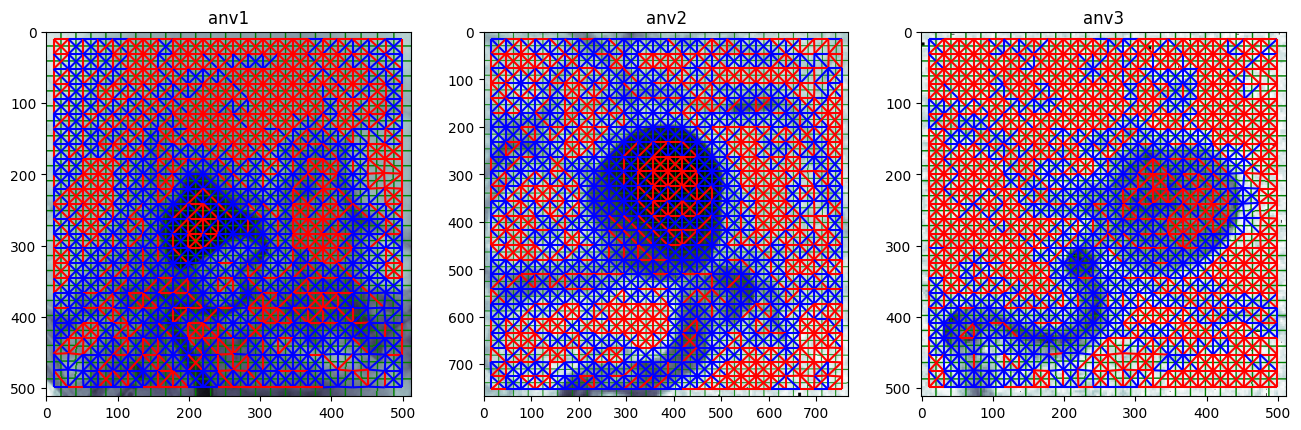

In [84]:
from skimage import graph
import matplotlib


def normalized_cut(img, label):
    
    g = graph.rag_mean_color(img, label, mode='similarity')
    labels2 = graph.cut_normalized(label, g)
    
    return g, labels2

blue_red = matplotlib.colors.ListedColormap(['blue', 'red'])

fig, ax = plt.subplots(ncols=3,  figsize=(16,10))
g_a1, labels2_a1 = normalized_cut(anv, labels_a1)

graph.show_rag(labels_a1, g_a1, color.gray2rgb(anv), border_color="green", edge_cmap=blue_red, ax = ax[0])
ax[0].set_title("anv1")

g_a2, labels2_a2 = normalized_cut(anv2, labels_a2)
graph.show_rag(labels_a2, g_a2, anv2, border_color="green", edge_cmap=blue_red, ax = ax[1])
ax[1].set_title("anv2")

g_a3, labels2_a3 = normalized_cut(anv3, labels_a3)
graph.show_rag(labels_a3, g_a3, anv3, border_color="green", edge_cmap=blue_red, ax = ax[2])
ax[2].set_title("anv3")

In [ ]:
### Get cut

# TODO : identify circular shape among the shape found

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10, np.int64(11): 11, np.int64(12): 12, np.int64(13): 13, np.int64(14): 14}
[ 0  1  2  3  4  5  6  7  8  9 10]
{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10}


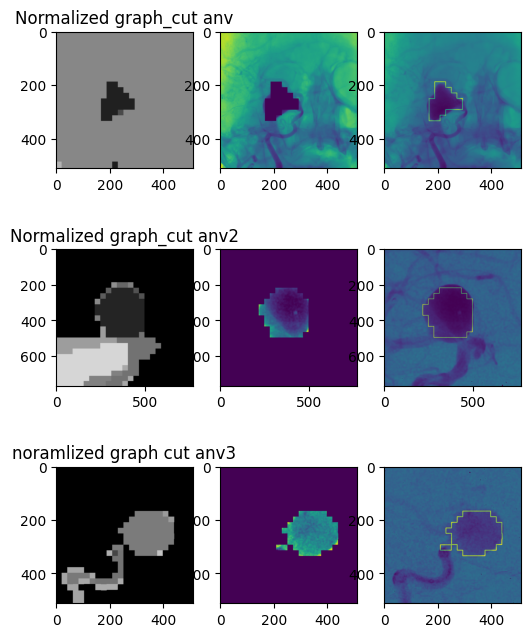

In [125]:
import cv2
def get_handable_labels(labels):
    unique_labels = np.unique(labels)
    print(unique_labels)
    look_up_table = { x:i for i, x in enumerate(unique_labels)}
    print(look_up_table)
    for x in range(labels.shape[0]):
        for y in range(labels.shape[1]):
            labels[x,y] = look_up_table[labels[x,y]]
    return labels, [i for i in range(unique_labels.shape[0])]

def get_contour(mask):

    contours, hierarchy = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )
    canvas = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    return cv2.drawContours(canvas, contours, -1, (0, 0, 255), 2)

fig, ax = plt.subplots(nrows=3, ncols=3,   figsize=(6, 8))
ax[0,0].imshow(color.label2rgb(labels2_a1, anv, kind='avg'))
ax[0,0].set_title("Normalized graph_cut anv")

ax[0,1].imshow(anv * (labels2_a1 != 228))

mask = ((labels2_a1 == 228)*255).astype(np.uint8)
cont = get_contour(mask)
ax[0,2].imshow( color.rgb2gray(cont)*2550 + anv)

ax[1,0].imshow(color.label2rgb(labels2_a2, anv2, kind='avg'))
ax[1,0].set_title("Normalized graph_cut anv2")

labels2_a2_h, lk_up_table = get_handable_labels(labels2_a2)
mask = (labels2_a2_h== lk_up_table[5]).astype(np.uint8)
cont = get_contour(mask)
ax[1,1].imshow(color.rgb2gray(anv2)* mask)

ax[1,2].imshow(color.rgb2gray(cont)*25 + color.rgb2gray(anv2))

ax[2,0].imshow(color.label2rgb(labels2_a3, anv3, kind='avg'))
ax[2,0].set_title("noramlized graph cut anv3")

labels2_a3_h, lk_up_table = get_handable_labels(labels2_a3)
mask = ((labels2_a3_h== lk_up_table[1])*255).astype(np.uint8)
cont = get_contour(mask)
ax[2,1].imshow(color.rgb2gray(anv3) * mask)
ax[2,2].imshow(color.rgb2gray(anv3) + color.rgb2gray(cont)*25)

In [40]:
lk_up_table

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

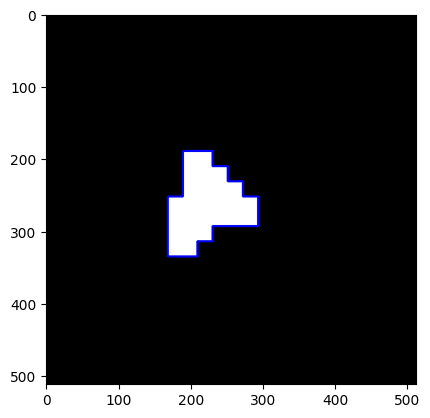

In [78]:

plt.imshow(val)

In [90]:
np.max(anv)

np.uint8(255)